In [111]:
import os
import json
import requests
from tqdm import tqdm
from glob import glob

# === CONFIG ===
SPECIES = [9606, 10090, 4932]  # human, mice, yeast
DATA_DIR = '../static/data'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

def fetch_confidence_score(source, target):
    identifiers = f"{source}%0d{target}"  # URL-encoded list of IDs separated by carriage return
    results = [] # {}
    udf_results = { # placeholder for when interaction is not found
            "organism": "N/A", 
            "score": 0.0, 
            "nscore": 0.0, 
            "fscore": 0.0, 
            "pscore": 0.0, 
            "ascore": 0.0, 
            "escore": 0.0, 
            "dscore": 0.0, 
            "tscore": 0.0
        }

    # finding edge between source and target
    found = False
    for species in SPECIES:
        url = f"https://string-db.org/api/json/network?identifiers={identifiers}&species={species}"
        try:
            response = requests.get(url)
            if response.status_code == 404:
                break

            response.raise_for_status()
            data = response.json()

            for edge in data:
                if (edge.get('preferredName_A') == source and edge.get('preferredName_B') == target) or \
                   (edge.get('preferredName_A') == target and edge.get('preferredName_B') == source):
                    
                    score_types = ['score', 'nscore', 'fscore', 'pscore', 'ascore', 'escore', 'dscore', 'tscore']
                    scores = {field: edge.get(field, 0.0) for field in score_types}
                    if any(value > 0 for value in scores.values()):
                        results.append({
                            "organism": species,
                            **scores
                        })
                        found = True
                    break

        except requests.exceptions.HTTPError as e:
            if response.status_code != 404:
                print(f"STRING API error for species {species}: {e}")

        except Exception as e:
            print(f"Unexpected error for species {species}: {e}")

    if not found:
        results.append(udf_results)
    return results


Found 194 files.


In [112]:
test_source = "POFUT1"
test_target = "F7"

score = fetch_confidence_score(test_source, test_target)
print(f"Confidence scores for interaction {test_source} -> {test_target}: {score}")

Confidence scores for interaction POFUT1 -> F7: [{'organism': 9606, 'score': 0.824, 'nscore': 0, 'fscore': 0, 'pscore': 0, 'ascore': 0.047, 'escore': 0.797, 'dscore': 0, 'tscore': 0.167}]


In [116]:
scores = fetch_confidence_score('zzzzccbbaaMBqqqqqqweweew333', 'MwewB33333')
print(f"Confidence scores for interaction zzzzccbbaaMBqqqqqqweweew333 -> MwewB33333: {scores}")

Confidence scores for interaction zzzzccbbaaMBqqqqqqweweew333 -> MwewB33333: [{'organism': 'N/A', 'score': 0.0, 'nscore': 0.0, 'fscore': 0.0, 'pscore': 0.0, 'ascore': 0.0, 'escore': 0.0, 'dscore': 0.0, 'tscore': 0.0}]


In [113]:
import re

def extract_number(filename):
    match = re.search(r'(\d+)\.json$', filename)
    return int(match.group(1)) if match else -1

files = sorted(files, key=extract_number)
filelist = files[:5]
filelist

['../static/data/graph_master_part100_0.json',
 '../static/data/graph_master_part100_1.json',
 '../static/data/graph_master_part100_2.json',
 '../static/data/graph_master_part100_3.json',
 '../static/data/graph_master_part100_4.json']

In [118]:
for file in tqdm(filelist):
    with open(file, "r") as f:
        data = json.load(f)

    links = data.get("links", [])
    new_links = []

    for link in links:
        src = str(link["source"])
        tgt = str(link["target"])
        id = str(link["id"])

        scores = fetch_confidence_score(src, tgt)
        # link.update(scores)
        for score_entry in scores:
            new_links.append({
                "source": src,
                "target": tgt,
                "id": id,
                **score_entry
            })

    data["links"] = new_links
    # saving to new folder
    OUTPUT_DIR = "../static/data/graph_master_scored"
    filename = os.path.basename(file)
    outname = os.path.join(OUTPUT_DIR, filename)
    with open(outname, "w") as f:
        json.dump(data, f, indent=2)


100%|██████████| 5/5 [13:20<00:00, 160.13s/it]


In [104]:
data

{'nodes': [{'id': 'CYTH1',
   'neighbors': ['PDZK1', 'CTNNB1'],
   'in_degree': [],
   'out_degree': ['PDZK1', 'CTNNB1'],
   'links': [{'source': {'id': 'CYTH1'},
     'target': {'id': 'PDZK1'},
     'source_neighbors': 1,
     'target_neighbors': 6},
    {'source': {'id': 'CYTH1'},
     'target': {'id': 'CTNNB1'},
     'source_neighbors': 1,
     'target_neighbors': 4}],
   'node_neighbor_count': 12},
  {'id': 'GPC3',
   'neighbors': ['PDGFRA', 'CLU', 'MPP2', 'FN1'],
   'in_degree': ['CLU', 'FN1'],
   'out_degree': ['MPP2', 'PDGFRA'],
   'links': [{'source': {'id': 'CLU'},
     'target': {'id': 'GPC3'},
     'source_neighbors': 6,
     'target_neighbors': 1,
     'color': 'orange',
     'penwidth': '5.0'},
    {'source': {'id': 'FN1'},
     'target': {'id': 'GPC3'},
     'source_neighbors': 2,
     'target_neighbors': 1},
    {'source': {'id': 'GPC3'},
     'target': {'id': 'MPP2'},
     'source_neighbors': 1,
     'target_neighbors': 1},
    {'source': {'id': 'GPC3'},
     'target': 

Reading graph files

In [105]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm import tqdm
from glob import glob

DATA_DIR = '../static/data/graph_master_scored'
FILE_PATTERN = os.path.join(DATA_DIR, "graph_master_part100_*.json")
files = sorted(glob(FILE_PATTERN))
print(f"Found {len(files)} files.")

Found 5 files.


In [106]:
scores = []
total_nodes = 0
total_links = 0

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        
        nodes = data.get("nodes", [])
        links = data.get("links", [])
        total_nodes += len(nodes)
        total_links += len(links)
        print(f"{file} has {len(links)} links")
        # print(f"{file} has {len(nodes)} nodes")

        for interaction in links:
            scores.append(interaction.get("score", 0.0))

print(f"Collected {len(scores)} scores for graph size {total_nodes}, {total_links}.")

../static/data/graph_master_scored/graph_master_part100_0.json has 1 links
../static/data/graph_master_scored/graph_master_part100_1.json has 294 links
../static/data/graph_master_scored/graph_master_part100_2.json has 342 links
../static/data/graph_master_scored/graph_master_part100_3.json has 209 links
../static/data/graph_master_scored/graph_master_part100_4.json has 199 links
Collected 1045 scores for graph size 402, 1045.


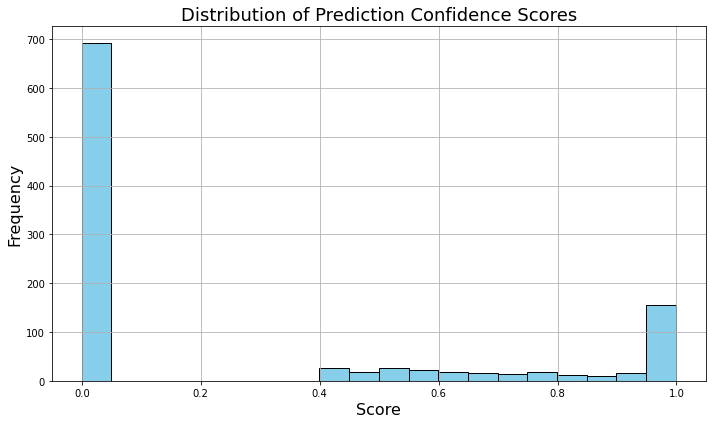

In [108]:
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Prediction Confidence Scores', fontsize=18)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.xlabel('Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
zero_scores = sum(1 for score in scores if score == 0.0)
total_scores = len(scores)

if total_scores > 0:
    percent_zero = (zero_scores / total_scores) * 100
    print(f"Zero scores: {zero_scores} / {total_scores} ({percent_zero:.2f}%)")
else:
    print("No scores found.")

Zero scores: 801 / 1222 (65.55%)


In [ ]:
non_zero_scores = [s for s in scores if s > 0.0]
high_scores = [s for s in non_zero_scores if 0.9 <= s <= 1.0]

if non_zero_scores:
    percent_high = (len(high_scores) / len(non_zero_scores)) * 100
    print(f"Scores between 0.9 and 1.0: {len(high_scores)} / {len(non_zero_scores)} ({percent_high:.2f}%)")

Scores between 0.9 and 1.0: 202 / 421 (47.98%)


Non-zero human score with at least one other non-zero score for a different species 

In [92]:
links = data.get('links', [])
links_with_scores = [link for link in links if (link["9606"].get("score", 0.0) > 0.0) \
                     and ((link["10090"].get("score", 0.0) > 0.0) \
                         or (link["4932"].get("score", 0.0) > 0.0))]

print(f"Links with human+other species score > 0.0: {len(links_with_scores)}")

Links with human+other species score > 0.0: 0


In [ ]:
from collections import defaultdict 

node_interaction_counts = defaultdict(int)

for file in files:
    with open(file, 'r') as f:
        data = json.load(f)
        links = data.get("links", [])
        for link in links:
            source = link.get("source")
            target = link.get("target")
            if source:
                node_interaction_counts[source] += 1
            if target:
                node_interaction_counts[target] += 1

In [34]:
len(node_interaction_counts)

486

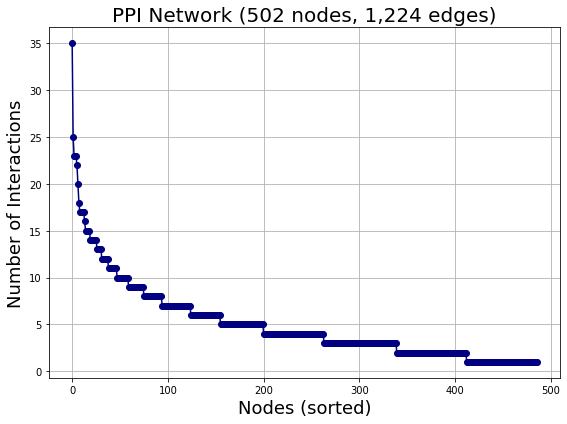

In [ ]:
# Sort nodes by interaction counts (descending)
sorted_nodes_counts = sorted(node_interaction_counts.items(), key=lambda x: x[1], reverse=True)
nodes_sorted, counts_sorted = zip(*sorted_nodes_counts)

# Plot interaction counts ordered by node rank
plt.figure(figsize=(8, 6))
plt.plot(counts_sorted, marker='o', linestyle='-', color='navy')
plt.title('PPI Network (502 nodes, 1,224 edges)', fontsize=20)
plt.xlabel('Nodes (sorted)', fontsize=18)
plt.ylabel('Number of Interactions', fontsize=18)
plt.grid(True)
plt.tight_layout()
plt.show()

Running KEGG enrichment with gprofiler

In [6]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)
gene_list = [node["id"] for node in data["nodes"]]
results = gp.profile(
    organism="hsapiens",  # or "mmusculus", "scerevisiae"
    query=gene_list,
    sources=["KEGG"]
)

In [24]:
len(gene_list)

100

In [17]:
results

,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,KEGG,KEGG:02010,ABC transporters,7.964192e-09,True,ABC transporters,45,72,9,8484,0.125000,0.200000,query_1,[KEGG:00000]
1,KEGG,KEGG:05203,Viral carcinogenesis,8.376104e-08,True,Viral carcinogenesis,201,72,14,8484,0.194444,0.069652,query_1,[KEGG:00000]
2,KEGG,KEGG:05200,Pathways in cancer,1.010423e-07,True,Pathways in cancer,527,72,21,8484,0.291667,0.039848,query_1,[KEGG:00000]
3,KEGG,KEGG:05207,Chemical carcinogenesis - receptor activation,1.574357e-06,True,Chemical carcinogenesis - receptor activation,211,72,13,8484,0.180556,0.061611,query_1,[KEGG:00000]
4,KEGG,KEGG:05219,Bladder cancer,3.535299e-06,True,Bladder cancer,41,72,7,8484,0.097222,0.170732,query_1,[KEGG:00000]
5,KEGG,KEGG:05225,Hepatocellular carcinoma,1.045637e-05,True,Hepatocellular carcinoma,166,72,11,8484,0.152778,0.066265,query_1,[KEGG:00000]
6,KEGG,KEGG:04110,Cell cycle,5.948851e-05,True,Cell cycle,157,72,10,8484,0.138889,0.063694,query_1,[KEGG:00000]
7,KEGG,KEGG:05215,Prostate cancer,1.202492e-04,True,Prostate cancer,97,72,8,8484,0.111111,0.082474,query_1,[KEGG:00000]
8,KEGG,KEGG:05034,Alcoholism,2.930813e-04,True,Alcoholism,187,72,10,8484,0.138889,0.053476,query_1,[KEGG:00000]
9,KEGG,KEGG:04919,Thyroid hormone signaling pathway,6.367563e-04,True,Thyroid hormone signaling pathway,121,72,8,8484,0.111111,0.066116,query_1,[KEGG:00000]


KEGG enrichment with GSEApy (https://github.com/zqfang/GSEApy)

In [37]:
import gseapy as gsea

enr = gsea.enrichr(
    gene_list=gene_list,
    gene_sets="KEGG_2021_Human",  
    organism="human",             
    outdir=None                 
)

In [8]:
enr.results.shape

(207, 10)

Incremental update to GSEApy

Initial load

In [63]:
human_scores = []
total_nodes = 0
total_links = 0

for i in range(5):
    file = files[i]
    with open(file, 'r') as f:
        data = json.load(f)
        
        nodes = data.get("nodes", [])
        links = data.get("links", [])
        total_nodes += len(nodes)
        total_links += len(links)
        print(f"{file} has {len(links)} links")
        # print(f"{file} has {len(nodes)} nodes")

        for interaction in links:
            if "9606" in interaction:
                human_score = interaction["9606"].get("score", 0.0)
                mouse_score = interaction.get("10090", {}).get("score", 0.0)
                yeast_score = interaction.get("4932", {}).get("score", 0.0)

                # Only include if human score is non-zero OR if all scores are zero
                if human_score != 0.0 or (mouse_score == 0.0 and yeast_score == 0.0):
                    human_scores.append(human_score) 

gene_list = [node["id"] for node in data["nodes"]]
enr = gsea.enrichr(
    gene_list=gene_list,
    gene_sets="KEGG_2021_Human",  
    organism="human",             
    outdir=None                 
)

../static/data/graph_master_scored/graph_master_part100_0.json has 1 links
../static/data/graph_master_scored/graph_master_part100_1.json has 294 links
../static/data/graph_master_scored/graph_master_part100_2.json has 342 links
../static/data/graph_master_scored/graph_master_part100_3.json has 209 links
../static/data/graph_master_scored/graph_master_part100_4.json has 199 links


In [64]:
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,ABC transporters,20/45,3.606117e-35,8.005579e-33,0,0,198.750000,15762.434538,ABCC3;ABCG8;ABCC1;ABCG5;ABCD3;ABCC2;ABCA5;ABCA...
1,KEGG_2021_Human,Bile secretion,9/90,6.838687e-10,7.590943e-08,0,0,24.199023,510.678161,ABCC3;ABCG8;ABCG5;ABCC2;RXRA;ABCB4;ABCB11;CYP3...
2,KEGG_2021_Human,Cholesterol metabolism,7/50,5.288019e-09,3.913134e-07,0,0,34.758440,662.420162,CYP27A1;ABCG8;ABCG5;CD36;LRP2;LDLRAP1;ABCB11
3,KEGG_2021_Human,Focal adhesion,10/201,6.630594e-08,3.679980e-06,0,0,11.465387,189.511222,PDGFRA;MAPK8;RAP1A;PRKCB;CAV2;ERBB2;FN1;CTNNB1...
4,KEGG_2021_Human,Proteoglycans in cancer,9/205,8.905705e-07,3.954133e-05,0,0,9.942588,138.514207,MRAS;PRKCB;CAV2;ERBB2;GPC3;FN1;CTNNB1;PRKCA;IGF1R
...,...,...,...,...,...,...,...,...,...,...
217,KEGG_2021_Human,Viral carcinogenesis,1/203,6.403882e-01,6.521385e-01,0,0,0.984998,0.438995,IRF3
218,KEGG_2021_Human,Human T-cell leukemia virus 1 infection,1/219,6.683867e-01,6.775427e-01,0,0,0.911964,0.367420,MAPK8
219,KEGG_2021_Human,Parkinson disease,1/249,7.151927e-01,7.185155e-01,0,0,0.800424,0.268305,MAPK8
220,KEGG_2021_Human,Herpes simplex virus 1 infection,2/498,7.152789e-01,7.185155e-01,0,0,0.798387,0.267526,IFNG;IRF3


In [41]:
import pandas as pd 
from collections import defaultdict

file = files[-1]
merged = defaultdict(list)
with open(file, 'r') as f:
    new_data = json.load(f)
    nodes = new_data.get("nodes", [])
    links = new_data.get("links", [])
    total_nodes += len(nodes)
    total_links += len(links)

    print(f"{file} has {len(links)} links")

    for interaction in links:
        if "9606" in interaction:
            human_score = interaction["9606"].get("score", 0.0)
            mouse_score = interaction.get("10090", {}).get("score", 0.0)
            yeast_score = interaction.get("4932", {}).get("score", 0.0)

            # Only include if human score is non-zero OR if all scores are zero
            if human_score != 0.0 or (mouse_score == 0.0 and yeast_score == 0.0):
                human_scores.append(human_score) 

../static/data/graph_master_scored/graph_master_part100_5.json has 179 links


In [ ]:
new_gene_list = [node["id"] for node in new_data["nodes"]]
enr = gsea.enrichr(
    gene_list=new_gene_list,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2021"],  
    organism="human",             
    outdir=None                 
)
enr.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Pathways in cancer,21/531,1.583534e-13,3.277915e-11,0,0,10.106478,297.877800,ITGB1;TCF7L1;HDAC2;GADD45A;LEF1;BRCA2;EPOR;HSP...
1,KEGG_2021_Human,ABC transporters,9/45,1.032061e-12,1.068183e-10,0,0,54.571429,1506.142165,ABCC4;ABCB6;ABCB7;ABCB8;ABCC9;ABCB9;ABCC11;ABC...
2,KEGG_2021_Human,Viral carcinogenesis,14/203,1.611734e-12,1.112097e-10,0,0,16.977606,461.004982,HDAC4;HDAC5;HDAC2;HDAC3;SRC;HDAC8;HDAC9;HDAC6;...
3,KEGG_2021_Human,Chemical carcinogenesis,13/239,2.071855e-10,1.072185e-08,0,0,13.007934,290.043197,UGT1A1;SRC;ARRB1;HSP90B1;VEGFA;NRAS;GSTA4;CCND...
4,KEGG_2021_Human,Hepatocellular carcinoma,11/168,7.850059e-10,3.249924e-08,0,0,15.542332,325.850110,NRAS;TCF7L1;GSTA4;CCND1;GSTA3;GADD45A;GSTA2;GS...
...,...,...,...,...,...,...,...,...,...,...
1740,GO_Biological_Process_2021,regulation of cell growth (GO:0001558),1/217,6.650086e-01,6.667426e-01,0,0,0.920501,0.375523,CEACAM1
1741,GO_Biological_Process_2021,regulation of cellular macromolecule biosynthe...,2/468,6.825875e-01,6.839215e-01,0,0,0.851099,0.325005,TCF7L1;BRCA2
1742,GO_Biological_Process_2021,positive regulation of cytokine production (GO...,1/335,8.161088e-01,8.171714e-01,0,0,0.591726,0.120243,IRF4
1743,GO_Biological_Process_2021,gene expression (GO:0010467),1/356,8.347880e-01,8.353311e-01,0,0,0.556125,0.100424,RANBP2


<Axes: title={'center': 'Gene Set Enrichment'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

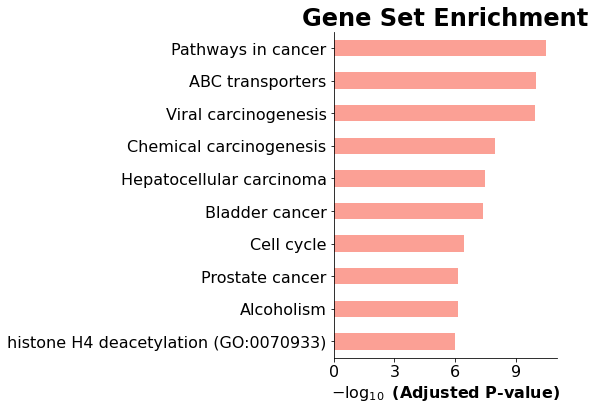

In [75]:
gsea.barplot(enr.results, title='Gene Set Enrichment', cutoff=0.05)

<Axes: title={'center': 'Top Terms'}, xlabel='Combined Score'>

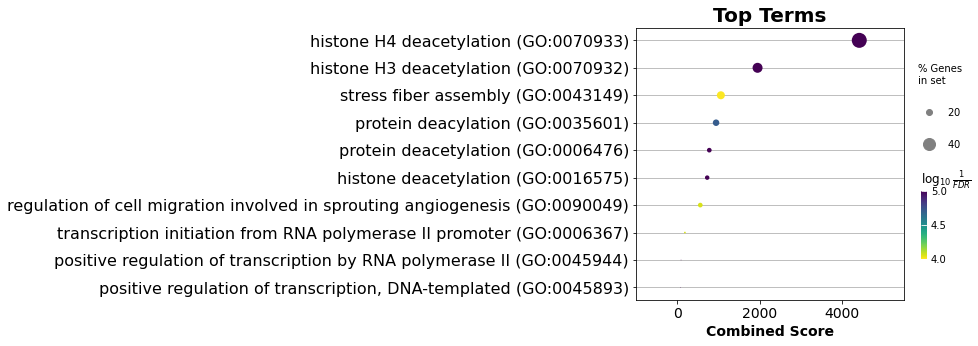

In [79]:
from gseapy import barplot, dotplot

dotplot(enr.res2d, 
        title='Top Terms', 
        cutoff=0.05, 
        figsize=(6,5))